<a href="https://www.kaggle.com/code/poeticmage/animal-with-attribute-2-notebook-data-upload?scriptVersionId=309062259" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Load Data for Animals With Attribute 2 Dataset (Awa2)
<p>The Awa2 Dataset is used mainly in zero shot learning. This notebook presents how one should prepare and upload data before training</p>
<h6>Reference: C. H. Lampert, H. Nickisch, and S. Harmeling. "Learning To Detect Unseen Object Classes by Between-Class Attribute Transfer". In CVPR, 2009 </h6>

### <h3>Upload dependencies,libraries, Install, Import</h3>
<p>We install all libraries and import the necessary functions. The %%capture shuts down all prints. Lightning is an important library that runs some training time functions that come handy. We use pytorch for our Computer Vision task. Just  Note that Pytorch operates with Dynamic Graph (The weight-value graph of the whole process is remade every epoch). Torchvision library is useful in image preprocessing. Transforms.Compose helps in conversion of image pixels to float as well as other augmentation like Clahe and Jitters. torch.utils.data gives us Dataset, that helps us to prepare our dataset in a class as they run typical functions like __len__ and __getitem__ , and DataLoader that finally prepares our train_loader and test_loader </p>
<h6>Note: ALWAYS CHECK FILE NAMES BEFORE USING</h6>

In [1]:
%%capture
! pip install scikit-learn numpy matplotlib pandas lightning torch timm==0.5.4
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import lightning as L
from torchvision import datasets, transforms
import numpy as np
import os
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

### <h3>Declare the transforms</h3>
<p>Declare the transforms.Compose because we will use this to convert our image to float type</p>

In [2]:
transform=transforms.Compose([transforms.ToTensor(),])

### <h3>Class dataset</h3>
<p> Build the Class and invoke the function Dataset from torch.utils.data so that it upload the input and prepares the data for train and test later. We extract image from file, strip and split the file name to get class name and get the corresponding attribute matrix after we have a class to index map. The class is the label index in order as given. Then we return the image, label and respective attribute side by side</p>
<h6>NB: Check the file-paths everytime you copy-paste this block</h6>

In [3]:
class AnimalDataset(Dataset):
    def __init__(self, classes_file_path, transform=None):
        self.transform = transform
        # 50x85 /kaggle/input/datasets/rrebirrth/animals-with-attributes-2
        self.predicate_binary_mat = np.genfromtxt(
            '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/predicate-matrix-binary.txt',
            dtype='int'
        )
        self.class_to_index = {}
        with open('/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/classes.txt') as f:
            for idx, line in enumerate(f):
                class_name = line.strip().split('\t')[1]
                self.class_to_index[class_name] = idx
        self.img_paths = []
        self.img_class_indices = [] 
        self.img_attr_vectors = []  
        with open(classes_file_path) as f:
            selected_classes = [line.strip() for line in f]
        for class_name in selected_classes:
            class_index = self.class_to_index[class_name]
            class_attr = self.predicate_binary_mat[class_index]
            folder_path = os.path.join(
                '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/JPEGImages',
                class_name
            )
            for img_path in glob(os.path.join(folder_path, '*.jpg')):
                self.img_paths.append(img_path)
                self.img_class_indices.append(class_index)
                self.img_attr_vectors.append(class_attr)
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        attr_vector = torch.tensor(self.img_attr_vectors[idx], dtype=torch.float32)
        class_index = self.img_class_indices[idx]  # true label
        return image, attr_vector, class_index, img_path 

### <h3>Prepare loaders</h3>
<p>Perform some augmentation and prepare the train_loader and test_loader here</p>

In [4]:
def get_data_loaders(train_classes_file, test_classes_file, batch_size=16):
    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_dataset = AnimalDataset(train_classes_file, transform=train_transform)
    test_dataset = AnimalDataset(test_classes_file, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, test_loader

### <h3>Use loader to build the final loader</h3>
<p>Use the above function and file name to upload the final train and test loader</p>


In [5]:
train_loader, test_loader = get_data_loaders(
    '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/trainclasses.txt',
    '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/testclasses.txt',
    batch_size=16
)

### <h3>Check loads</h3>
<p>Check the size, shape, etc. of your inputs</p>

In [6]:
images,attrs, label, paths = next(iter(train_loader))

print("Images shape:", images.shape)
print("Attributes shape:", label.shape)
print("First image path:", paths[0])

Images shape: torch.Size([16, 3, 224, 224])
Attributes shape: torch.Size([16])
First image path: /kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/JPEGImages/otter/otter_10083.jpg


### <h3>Visualize data</h3>
<p>Get one image, its attribute, and path. Convert to numpy after rearranging the image tensor of 3(C)x224(H)x224(W) to image first, channel later (the way to visualize image) : HxWxC where BxCxHxW are Batch, Channel (3 initially for RGB), Height and Width. Use pyplot imshow for visualization</p>

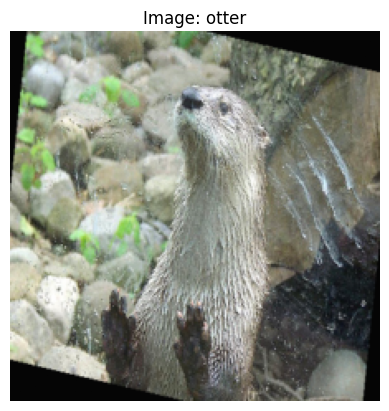

Attribute vector for this image:
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0]
/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/JPEGImages/otter/otter_10083.jpg


In [7]:
import matplotlib.pyplot as plt
# Get one image, its attribute, and path
image, attr, label, path = images[0], attrs[0], label[0], paths[0]

image_np = image.permute(1, 2, 0).cpu().numpy()

plt.imshow(image_np)
plt.axis('off')
plt.title("Image: " + path.split('/')[-2])
plt.show()

print("Attribute vector for this image:")
print(attr.int().tolist())
print(path)


### Check the first test loader
<p> Check the test loader too with the first instance</p>

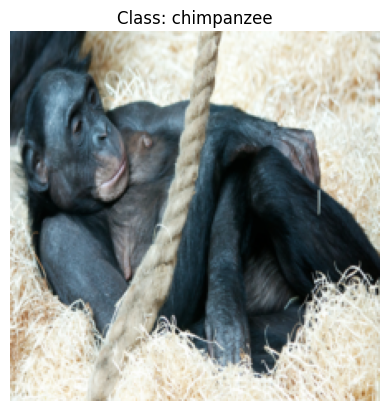

Attribute vector for 'chimpanzee':
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1]


In [8]:
for images, attrs, label, paths in test_loader:
    for i in range(len(images)):
        image = images[i]
        attr = attrs[i]
        path = paths[i]

        image_np = image.permute(1, 2, 0).cpu().numpy()

        class_name = path.split('/')[-2]

        plt.imshow(image_np)
        plt.axis('off')
        plt.title(f"Class: {class_name}")
        plt.show()

        print(f"Attribute vector for '{class_name}':\n{attr.int().tolist()}")
        
        break
    break

### <h1>NOW YOU CAN USE THIS AS DATALOADER TO USE IN ANY MODEL</h1>

<p>This is how I typically used it in my model</p>

```
from pytorch_lightning.loggers import CSVLogger

aca='/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/predicate-matrix-binary.txt'

all_class_attributes = torch.tensor(
    np.genfromtxt(aca, dtype='int'),
    dtype=torch.float32
)

logger = CSVLogger("logs/", name="zsl_training")

model = LocalAttentionZSLNet(all_class_attrs=all_class_attributes)

trainer = L.Trainer(
    max_epochs=20,
    accelerator='auto'
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=[train_loader, test_loader])
 
```

### Cutting down low variance Attributes
You may like to cut down low variance attribute to see whether these are nuisance variables, as often they are understood as so. You may use Standard Scaler to normalize values across columns and then us Principal Component Analysis to retain only vectors that show 95% variance.

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
aca='/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/predicate-matrix-binary.txt'
all_class_attributes = torch.tensor(
    np.genfromtxt(aca, dtype='int'),
    dtype=torch.float32
)
all_class_np = all_class_attributes.cpu().numpy()
all_class_np=StandardScaler().fit_transform(all_class_np)
pca=PCA(n_components=0.95)
reduced_np=pca.fit_transform(all_class_np)
all_class_attributes_reduced = torch.tensor(reduced_np, dtype=torch.float32)
print(all_class_attributes_reduced.shape[1])

31


### Save your new Attribute vectors

In [10]:
print(all_class_attributes_reduced)
save_path = "/kaggle/working/all_class_attributes_reduced.pt"
torch.save(all_class_attributes_reduced, save_path)

tensor([[-3.3088e-01,  4.2035e+00,  1.7043e+00,  ..., -6.1488e-01,
          4.6069e-03,  9.9989e-01],
        [ 2.1167e+00, -2.4237e+00,  2.1832e+00,  ...,  9.7250e-02,
         -3.0464e-01, -4.0133e-01],
        [-6.5181e+00, -6.0253e+00,  1.9577e+00,  ...,  1.1980e+00,
          2.9226e-01,  8.9412e-01],
        ...,
        [ 4.6151e+00, -2.1440e+00, -1.4180e+00,  ..., -5.2836e-01,
          1.3578e-01,  9.6064e-02],
        [-2.0345e+00,  5.5366e+00, -7.7483e-01,  ..., -2.5684e-01,
          8.0235e-02, -9.0084e-02],
        [-6.1118e+00, -3.4660e+00, -2.2237e-01,  ..., -7.8526e-01,
         -4.0578e-02,  4.7883e-01]])
